# Zero-DCE: Zero-Reference Deep Curve Estimation

> **Giới thiệu:** Zero-DCE là một phương pháp nâng cao độ sáng hình ảnh thiếu sáng mà không cần ảnh tham chiếu (Ground-truth). Nó ước tính các hệ số của đường cong (Light Enhancement Curves) để điều chỉnh dải động của ảnh một cách mượt mà và tự nhiên.

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

# Kết nối Drive nếu cần thiết
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

### 2. Cấu hình Hyperparameters (Config)

In [20]:
class Config:
    lr = 1e-4
    weight_decay = 1e-4
    grad_clip_norm = 0.1
    num_epochs = 100
    batch_size = 16
    img_size = 256

    # Đã cập nhật lại đường dẫn chính xác dựa trên kết quả kiểm tra
    train_dir = '/content/drive/MyDrive/Colab Notebooks/zerodce/lol_dataset/our485'
    save_model_path = 'model_checkpoints/'

    # Trọng số hàm Loss
    w_spa = 1.0
    w_exp = 10.0
    w_col = 5.0
    w_tv = 200.0

args = Config()
os.makedirs(args.save_model_path, exist_ok=True)
print(f"Cấu hình đã sẵn sàng. Thư mục huấn luyện: {args.train_dir}")

Cấu hình đã sẵn sàng. Thư mục huấn luyện: /content/drive/MyDrive/Colab Notebooks/zerodce/lol_dataset/our485


### 3. Data Loader

Lớp `LowLightDataset` sẽ đọc các ảnh thiếu sáng và chuẩn hóa về dải `[0, 1]`.

In [21]:
import os
import glob

# Kiểm tra thư mục trước khi khởi tạo Dataset
if not os.path.exists(args.train_dir):
    print(f"⚠️ LỖI: Không tìm thấy thư mục tại: {args.train_dir}")
else:
    class LowLightDataset(Dataset):
        def __init__(self, image_dir, transform=None):
            self.image_dir = image_dir
            # Tìm kiếm đệ quy để tránh trường hợp ảnh nằm trong thư mục con (như our485/low/)
            self.image_list = []
            for ext in ('*.jpg', '*.png', '*.jpeg', '*.JPG', '*.PNG'):
                self.image_list.extend(glob.glob(os.path.join(image_dir, "**/" + ext), recursive=True))

            self.transform = transform

        def __len__(self):
            return len(self.image_list)

        def __getitem__(self, idx):
            img_path = self.image_list[idx]
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image

    transform = transforms.Compose([
        transforms.Resize((args.img_size, args.img_size)),
        transforms.ToTensor(),
    ])

    train_dataset = LowLightDataset(args.train_dir, transform=transform)

    if len(train_dataset) == 0:
        print(f"⚠️ CẢNH BÁO: Không tìm thấy ảnh nào trong {args.train_dir}")
        print("Gợi ý: Kiểm tra xem ảnh có nằm trong thư mục con như 'low' hay không.")
    else:
        train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=2)
        print(f"✅ Đã tìm thấy {len(train_dataset)} ảnh. Data loader đã sẵn sàng.")

✅ Đã tìm thấy 970 ảnh. Data loader đã sẵn sàng.


In [22]:
import os
# Liệt kê các thư mục trong 'zerodce' để kiểm tra cấu trúc thực tế
base_path = '/content/drive/MyDrive/Colab Notebooks/zerodce/'
if os.path.exists(base_path):
    print(f"Danh sách các mục trong {base_path}:")
    print(os.listdir(base_path))
else:
    print("Không tìm thấy thư mục 'zerodce'. Hãy đảm bảo bạn đã mount Drive thành công.")

Danh sách các mục trong /content/drive/MyDrive/Colab Notebooks/zerodce/:
['lol_dataset', 'Zero-DCE.ipynb', 'model_checkpoints']


In [23]:
import os
# Kiểm tra sâu hơn vào trong lol_dataset
lol_path = '/content/drive/MyDrive/Colab Notebooks/zerodce/lol_dataset/'
if os.path.exists(lol_path):
    print(f"Nội dung bên trong {lol_path}:")
    print(os.listdir(lol_path))
else:
    print("Không tìm thấy lol_dataset")

Nội dung bên trong /content/drive/MyDrive/Colab Notebooks/zerodce/lol_dataset/:
['eval15', 'our485']


### 4. Kiến trúc Model Zero-DCE

Sử dụng 7 tầng Convolution với kết nối tắt (Skip connection) để dự đoán 24 kênh (8 vòng lặp * 3 kênh màu).

In [24]:
class DeepCurveEstimationNet(nn.Module):
    def __init__(self):
        super(DeepCurveEstimationNet, self).__init__()
        self.relu = nn.ReLU(inplace=True)

        self.e_conv1 = nn.Conv2d(3, 32, 3, 1, 1, bias=True)
        self.e_conv2 = nn.Conv2d(32, 32, 3, 1, 1, bias=True)
        self.e_conv3 = nn.Conv2d(32, 32, 3, 1, 1, bias=True)
        self.e_conv4 = nn.Conv2d(32, 32, 3, 1, 1, bias=True)
        self.e_conv5 = nn.Conv2d(64, 32, 3, 1, 1, bias=True) # Concatenation layer
        self.e_conv6 = nn.Conv2d(64, 32, 3, 1, 1, bias=True) # Concatenation layer
        self.e_conv7 = nn.Conv2d(96, 24, 3, 1, 1, bias=True) # Output layer (8*3 channels)

    def forward(self, x):
        x1 = self.relu(self.e_conv1(x))
        x2 = self.relu(self.e_conv2(x1))
        x3 = self.relu(self.e_conv3(x2))
        x4 = self.relu(self.e_conv4(x3))
        x5 = self.relu(self.e_conv5(torch.cat([x3, x4], 1)))
        x6 = self.relu(self.e_conv6(torch.cat([x2, x5], 1)))
        x_r = torch.tanh(self.e_conv7(torch.cat([x1, x2, x6], 1)))

        # Apply Higher-Order Curve iterative: LE(x, A) = x + A*x*(1-x)
        enhanced_image = x
        for i in range(0, 24, 3):
            a = x_r[:, i:i+3, :, :]
            enhanced_image = enhanced_image + a * (torch.pow(enhanced_image, 2) - enhanced_image) * -1

        return enhanced_image, x_r

### 5. Custom Non-Reference Loss Functions

Định nghĩa 4 thành phần Loss theo Paper.

In [25]:
class L_spa(nn.Module):
    def __init__(self):
        super(L_spa, self).__init__()
        kernel_left = torch.FloatTensor([[0,0,0],[-1,1,0],[0,0,0]]).unsqueeze(0).unsqueeze(0)
        kernel_right = torch.FloatTensor([[0,0,0],[0,1,-1],[0,0,0]]).unsqueeze(0).unsqueeze(0)
        kernel_up = torch.FloatTensor([[0,-1,0],[0,1,0],[0,0,0]]).unsqueeze(0).unsqueeze(0)
        kernel_down = torch.FloatTensor([[0,0,0],[0,1,0],[0,-1,0]]).unsqueeze(0).unsqueeze(0)
        self.weight_left = nn.Parameter(data=kernel_left, requires_grad=False)
        self.weight_right = nn.Parameter(data=kernel_right, requires_grad=False)
        self.weight_up = nn.Parameter(data=kernel_up, requires_grad=False)
        self.weight_down = nn.Parameter(data=kernel_down, requires_grad=False)
        self.pool = nn.AvgPool2d(4)

    def forward(self, org, enhance):
        org_mean = torch.mean(org, 1, keepdim=True)
        enhance_mean = torch.mean(enhance, 1, keepdim=True)
        org_pool = self.pool(org_mean)
        enhance_pool = self.pool(enhance_mean)
        d_org_l = F.conv2d(org_pool, self.weight_left, padding=1)
        d_org_r = F.conv2d(org_pool, self.weight_right, padding=1)
        d_org_u = F.conv2d(org_pool, self.weight_up, padding=1)
        d_org_d = F.conv2d(org_pool, self.weight_down, padding=1)
        d_enh_l = F.conv2d(enhance_pool, self.weight_left, padding=1)
        d_enh_r = F.conv2d(enhance_pool, self.weight_right, padding=1)
        d_enh_u = F.conv2d(enhance_pool, self.weight_up, padding=1)
        d_enh_d = F.conv2d(enhance_pool, self.weight_down, padding=1)
        loss = torch.pow(d_org_l-d_enh_l,2) + torch.pow(d_org_r-d_enh_r,2) + torch.pow(d_org_u-d_enh_u,2) + torch.pow(d_org_d-d_enh_d,2)
        return torch.mean(loss)

class L_exp(nn.Module):
    def __init__(self, patch_size=16, mean_val=0.6):
        super(L_exp, self).__init__()
        self.pool = nn.AvgPool2d(patch_size)
        self.mean_val = mean_val
    def forward(self, x):
        x = torch.mean(x, 1, keepdim=True)
        mean = self.pool(x)
        return torch.mean(torch.pow(mean - self.mean_val, 2))

class L_col(nn.Module):
    def __init__(self):
        super(L_col, self).__init__()
    def forward(self, x):
        mean_rgb = torch.mean(x, [2, 3])
        mr, mg, mb = mean_rgb[:, 0], mean_rgb[:, 1], mean_rgb[:, 2]
        loss = torch.pow(mr - mg, 2) + torch.pow(mr - mb, 2) + torch.pow(mg - mb, 2)
        return torch.mean(loss)

class L_tv(nn.Module):
    def __init__(self):
        super(L_tv, self).__init__()
    def forward(self, x):
        batch_size, c, h, w = x.shape
        count_h = (h - 1) * w
        count_w = h * (w - 1)
        h_tv = torch.pow((x[:, :, 1:, :] - x[:, :, :h - 1, :]), 2).sum()
        w_tv = torch.pow((x[:, :, :, 1:] - x[:, :, :, :w - 1]), 2).sum()
        return 2 * (h_tv / count_h + w_tv / count_w) / batch_size

### 6. Khởi tạo & Vòng lặp Huấn luyện (Training Loop)

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepCurveEstimationNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

# Khởi tạo loss modules
criterion_spa = L_spa().to(device)
criterion_exp = L_exp().to(device)
criterion_col = L_col().to(device)
criterion_tv = L_tv().to(device)

print("Bắt đầu huấn luyện...")
for epoch in range(args.num_epochs):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{args.num_epochs}")

    for img_low in progress_bar:
        img_low = img_low.to(device)

        enhanced_img, A = model(img_low)

        loss_spa = criterion_spa(img_low, enhanced_img)
        loss_exp = criterion_exp(enhanced_img)
        loss_col = criterion_col(enhanced_img)
        loss_tv = criterion_tv(A)

        total_loss = args.w_spa * loss_spa + args.w_exp * loss_exp + \
                     args.w_col * loss_col + args.w_tv * loss_tv

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), args.grad_clip_norm)
        optimizer.step()

        epoch_loss += total_loss.item()
        progress_bar.set_postfix(loss=total_loss.item())

    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"{args.save_model_path}epoch_{epoch+1}.pth")
        print(f"--- Đã lưu checkpoint tại epoch {epoch+1} ---")

Bắt đầu huấn luyện...


Epoch 10/100: 100%|██████████| 61/61 [00:18<00:00,  3.26it/s, loss=0.59]


--- Đã lưu checkpoint tại epoch 10 ---


Epoch 20/100: 100%|██████████| 61/61 [00:19<00:00,  3.19it/s, loss=0.452]


--- Đã lưu checkpoint tại epoch 20 ---


...

--- Đã lưu checkpoint tại epoch 80 ---


Epoch 90/100: 100%|██████████| 61/61 [00:19<00:00,  3.19it/s, loss=0.599]


--- Đã lưu checkpoint tại epoch 90 ---


Epoch 100/100: 100%|██████████| 61/61 [00:18<00:00,  3.26it/s, loss=0.661]

--- Đã lưu checkpoint tại epoch 100 ---


### 7. Hàm Kiểm thử (Inference) & Trực quan hóa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [27]:
def enhance_image(model, image_path):
    model.eval()
    raw_image = Image.open(image_path).convert('RGB')
    input_image = transform(raw_image).unsqueeze(0).to(device)

    with torch.no_grad():
        enhanced_image, _ = model(input_image)

    # Chuyển tensor về numpy để plot
    enhanced_image = enhanced_image.squeeze().cpu().permute(1, 2, 0).numpy()
    enhanced_image = np.clip(enhanced_image, 0, 1)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(raw_image)
    plt.title("Original Low-light")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(enhanced_image)
    plt.title("Zero-DCE Enhanced")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ví dụ chạy test (Thay đổi đường dẫn file cụ thể trong dataset của bạn)
# enhance_image(model, os.path.join(args.train_dir, os.listdir(args.train_dir)[0]))

### 8. Xuất Model sang định dạng ONNX
Sử dụng `torch.onnx.export` để chuyển đổi model sang định dạng ONNX giúp triển khai trên nhiều nền tảng khác nhau.

In [28]:
!pip install onnx onnxscript

In [29]:
def export_to_onnx(model, save_path, img_size=256):
    model.eval()
    # Tạo dữ liệu giả lập (dummy input) có cùng kích thước với đầu vào của model
    dummy_input = torch.randn(1, 3, img_size, img_size).to(device)

    torch.onnx.export(
        model,
        dummy_input,
        save_path,
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output', 'curves'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
    )
    print(f"✅ Model đã được xuất sang: {save_path}")

# Xuất thử model hiện tại (ngay cả khi chưa training xong)
onnx_path = os.path.join(args.save_model_path, "zerodce_model.onnx")
export_to_onnx(model, onnx_path)

/tmp/ipykernel_896/814444907.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0525 14:48:05.014000 896 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0525 14:48:06.169000 896 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, 

[torch.onnx] Obtain model graph for `DeepCurveEstimationNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DeepCurveEstimationNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✅ Model đã được xuất sang: model_checkpoints/zerodce_model.onnx


In [1]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 97.2 MB/s eta 0:00:00


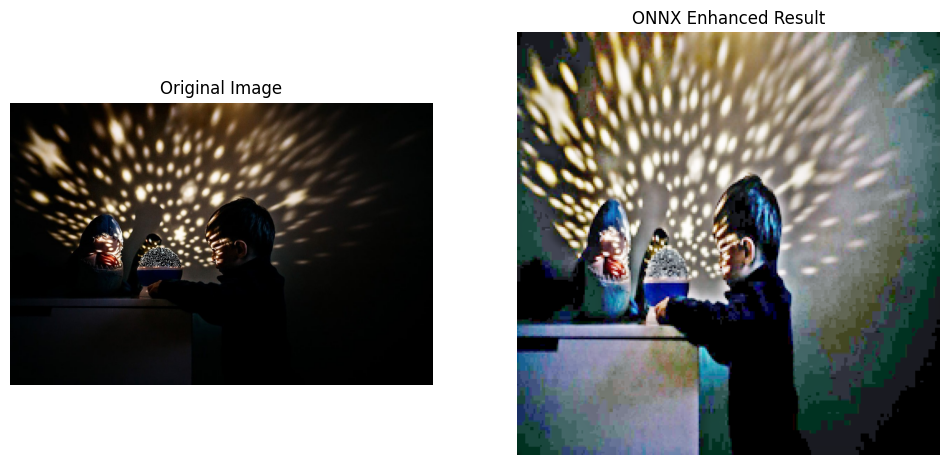

In [2]:
import onnxruntime as ort
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def test_onnx_model(onnx_path, image_path):
    # 1. Load model ONNX
    session = ort.InferenceSession(onnx_path)

    # 2. Tiền xử lý ảnh
    raw_image = Image.open(image_path).convert('RGB')
    raw_image_resized = raw_image.resize((256, 256))
    img_data = np.array(raw_image_resized).astype(np.float32) / 255.0
    img_data = np.transpose(img_data, (2, 0, 1)) # HWC to CHW
    img_data = np.expand_dims(img_data, axis=0)  # Thêm batch dimension

    # 3. Chạy Inference
    input_name = session.get_inputs()[0].name
    outputs = session.run(None, {input_name: img_data})
    enhanced_output = outputs[0] # Lấy tensor ảnh đầu ra

    # 4. Hậu xử lý để hiển thị
    output_img = np.squeeze(enhanced_output)
    output_img = np.transpose(output_img, (1, 2, 0))
    output_img = np.clip(output_img, 0, 1)

    # 5. Hiển thị kết quả
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(raw_image)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(output_img)
    plt.title("ONNX Enhanced Result")
    plt.axis('off')
    plt.show()

# Đường dẫn file
onnx_model_path = '/content/drive/MyDrive/Colab Notebooks/zerodce/model_checkpoints/zerodce_model.onnx'
test_img_path = '/content/drive/MyDrive/Colab Notebooks/zerodce/test_image.jpg'

test_onnx_model(onnx_model_path, test_img_path)